<a href="https://colab.research.google.com/github/jeffheaton/app_deep_learning/blob/main/t81_558_class_10_4_emotion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# T81-558: Applications of Deep Neural Networks

**Module 10: Facial Processing**

* Instructor: [Jeff Heaton](https://sites.washu.edu/jeffheaton/), McKelvey School of Engineering, [Washington University in St. Louis](https://engineering.washu.edu/index.html)
* For more information visit the [class website](https://sites.washu.edu/jeffheaton/t81-558/).

# Module 10 Material

- Part 10.1: Detecting Faces in an Image [[Video]]() [[Notebook]](t81_558_class_10_1_faces.ipynb)
- Part 10.2: Detecting Facial Features [[Video]]() [[Notebook]](t81_558_class_10_2_face_landmarks.ipynb)
- Part 10.3: Reality Augmentation [[Video]]() [[Notebook]](t81_558_class_10_3_reality_augmentation.ipynb)
- **Part 10.4: Application: Emotion Detection** [[Video]]() [[Notebook]](t81_558_class_10_4_emotion.ipynb)
- Part 10.5: Dynaface [[Video]]() [[Notebook]](t81_558_class_10_5_dynaface.ipynb)

# Google CoLab Instructions

The following code checks that Google CoLab is and sets up the correct hardware settings for PyTorch.


In [1]:
try:
    import google.colab
    COLAB = True
    print("Note: using Google CoLab")
except:
    print("Note: not using Google CoLab")
    COLAB = False

!pip install -q deepface opencv-python matplotlib requests

# Make use of a GPU or MPS (Apple) if one is available.  (see module 3.2)
import torch
has_mps = torch.backends.mps.is_available()
device = "mps" if has_mps else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Note: using Google CoLab
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 65.6 MB/s eta 0:00:00
Using device: cpu


# Part 10.4: Application: Emotion Detection

So far in Module 10 we have detected faces (Part 10.1), extracted dense facial landmarks (Part 10.2), and used those landmarks as anchors for augmentation (Part 10.3). Each step has moved us further along the same arc: from "is there a face" to "where are its parts" to "what can we do with that geometry." This notebook takes the next step: interpreting what the face is *expressing*.

Emotion recognition from a still image is a classic computer vision task. The goal is to take a cropped face and assign it a probability over a small set of categorical emotions, typically the seven described by Ekman: anger, disgust, fear, happiness, sadness, surprise, and neutral. The training data for these classifiers is usually FER2013 or a derivative, which means the predictions are coarse and the models pick up on photographic conventions (lighting, framing, posed expressions) as much as on the underlying emotion. They are useful for aggregate analytics and demos, less reliable for individual judgments. Treat the output as a signal, not a verdict.

The applications are familiar:

* **Audience analytics**: Marketers and product teams measure how viewers react to ads, trailers, and prototypes.
* **Adaptive content**: Games and learning tools adjust difficulty or pacing based on the viewer's expression.
* **Healthcare and accessibility**: Clinicians and assistive tech use expression cues to monitor pain, fatigue, or engagement, particularly with patients who have difficulty communicating verbally.
* **Driver and operator monitoring**: Detecting drowsiness, distraction, or distress in safety-critical roles.

For this notebook we use [DeepFace](https://github.com/serengil/deepface), an actively maintained Python library that wraps a number of pre-trained face analysis models behind a single `analyze` function. DeepFace can return age, gender, race, and emotion in one call, and it lets you pick which face detector to use under the hood. We use the MediaPipe detector backend, which keeps this notebook consistent with the rest of Module 10. The previous version of this notebook used the `fer` package, which still works but pulls in a heavier TensorFlow + MTCNN + moviepy dependency stack and offers a narrower API.


## Loading the input image

We start with a portrait downloaded from a URL. The pattern is the same one used in Parts 10.2 and 10.3: fetch the bytes with `requests`, decode through OpenCV, and convert from BGR to RGB so that everything downstream (matplotlib, DeepFace) sees the channel order it expects.

We also resize the image to a fixed display width. This keeps the figure size predictable across input images and is a good reminder that the model itself works on a much smaller internal crop, so the resize does not change the prediction quality in any meaningful way.


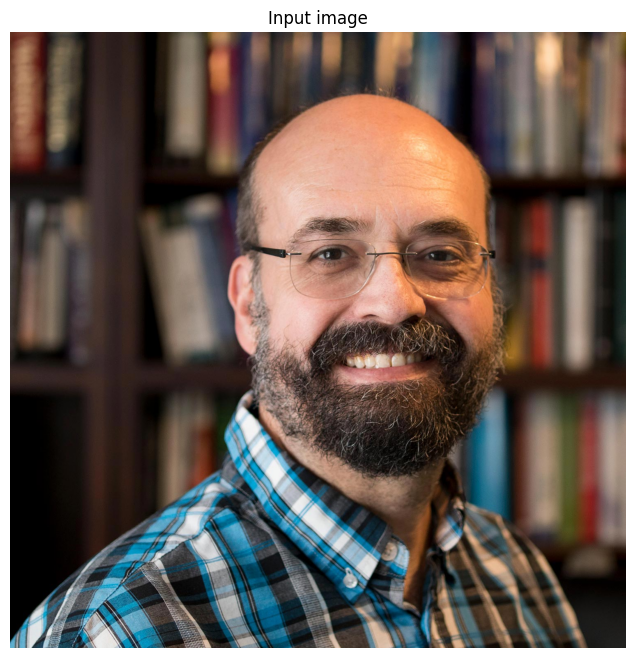

In [2]:
import requests
import cv2
import numpy as np
import matplotlib.pyplot as plt


def load_image_from_url(url):
    response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
    response.raise_for_status()

    image_array = np.frombuffer(response.content, np.uint8)
    bgr = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

    if bgr is None:
        raise ValueError("Could not decode image. Try a direct JPG or PNG URL.")

    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def display_image(rgb, title=None):
    plt.figure(figsize=(8, 8))
    plt.imshow(rgb)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()


URL_NEUTRAL = "https://data.heatonresearch.com/images/jeff/about-jeff-heaton-2020.jpg"

img_neutral = load_image_from_url(URL_NEUTRAL)
display_image(img_neutral, title="Input image")

## Running emotion detection

DeepFace's `analyze` function does the whole pipeline in one call: it detects the face, crops and aligns it, runs the emotion classifier, and returns the per-class probabilities along with the bounding box.

A few arguments worth knowing:

* `actions=['emotion']` tells DeepFace to skip age, gender, and race and only run the emotion model. Each action loads its own pre-trained model the first time it is requested, so limiting the action list speeds up the first call.
* `detector_backend='retinaface'` selects the face detector that runs before the emotion model. DeepFace supports several backends including `opencv`, `ssd`, `mtcnn`, `retinaface`, and various YOLO variants. RetinaFace is slower than the OpenCV default but noticeably more accurate, which matters because if the face crop is off the emotion model's input is junk. (DeepFace also offers a `mediapipe` backend, but it depends on the legacy `mp.solutions` API and breaks against current MediaPipe releases, so we steer clear of it here.)
* `enforce_detection=False` makes DeepFace return a result even when its confidence in the face crop is low, rather than raising an exception. This is useful for batch processing where you want to inspect borderline cases rather than have them throw.

The first call downloads the emotion and RetinaFace model weights (a few tens of MB total) and caches them under `~/.deepface/`. Subsequent calls reuse the cached weights.


In [3]:
from deepface import DeepFace

# DeepFace expects BGR by default (it calls cv2 internally). Pass the original
# image rather than our RGB-converted display copy, or convert back.
img_bgr = cv2.cvtColor(img_neutral, cv2.COLOR_RGB2BGR)

results = DeepFace.analyze(
    img_path=img_bgr,
    actions=["emotion"],
    detector_backend="retinaface",
    enforce_detection=False,
)

result = results[0]
print(f"Dominant emotion: {result['dominant_emotion']}")
print()
print("Per-class probabilities:")
for emotion, score in sorted(result["emotion"].items(), key=lambda kv: -kv[1]):
    print(f"  {emotion:10s} {score:6.2f}%")

26-05-03 22:43:28 - Directory /root/.deepface has been created
26-05-03 22:43:28 - Directory /root/.deepface/weights has been created
26-05-03 22:43:30 - retinaface.h5 will be downloaded from the url https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5
To: /root/.deepface/weights/retinaface.h5
100%|██████████| 119M/119M [00:00<00:00, 190MB/s]
Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5
To: /root/.deepface/weights/facial_expression_model_weights.h5


26-05-03 22:43:36 - 🔗 facial_expression_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5 to /root/.deepface/weights/facial_expression_model_weights.h5...


100%|██████████| 5.98M/5.98M [00:00<00:00, 75.4MB/s]

Dominant emotion: happy

Per-class probabilities:
  happy       97.99%
  neutral      2.00%
  sad          0.00%
  angry        0.00%
  fear         0.00%
  surprise     0.00%
  disgust      0.00%


## Visualizing the result

DeepFace returns the bounding box of the detected face in the `region` field. We can use that to draw a labeled rectangle over the image, which makes the result easier to read at a glance and matches the visualization style of the augmented-reality work in Part 10.3.


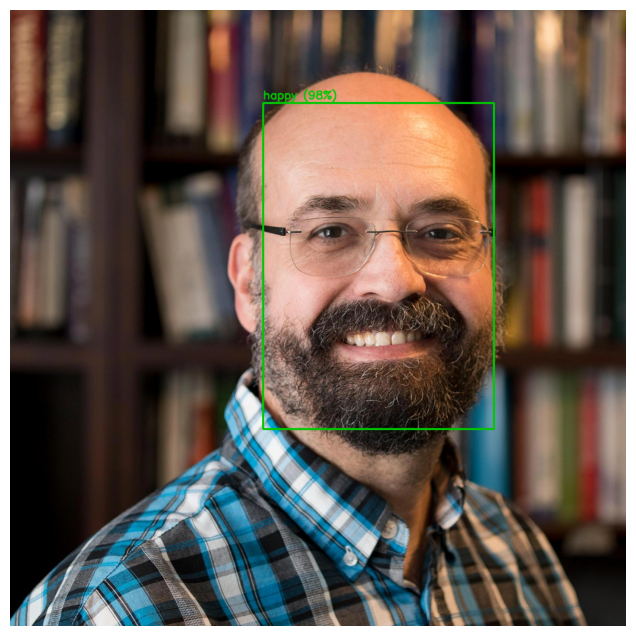

In [4]:
def draw_emotion(rgb, result, color=(0, 200, 0), thickness=3):
    annotated = rgb.copy()

    region = result["region"]
    x, y = region["x"], region["y"]
    w, h = region["w"], region["h"]

    cv2.rectangle(annotated, (x, y), (x + w, y + h), color, thickness)

    label = f"{result['dominant_emotion']} ({result['emotion'][result['dominant_emotion']]:.0f}%)"
    cv2.putText(
        annotated,
        label,
        (x, max(y - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        color,
        2,
        cv2.LINE_AA,
    )

    return annotated


annotated = draw_emotion(img_neutral, result)
display_image(annotated)

## A more expressive face

A neutral portrait is a tough test for an emotion classifier because the dominant signal is, by design, faint. Let's try a more obviously emotional photo and see whether the model picks up on it.


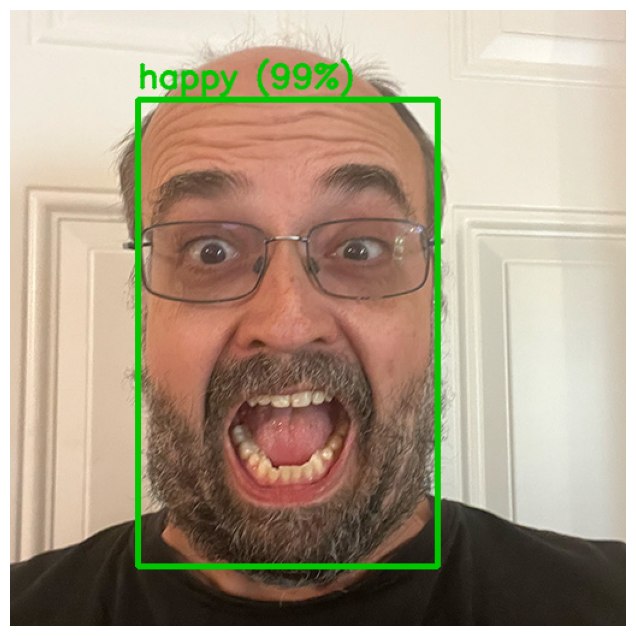

Dominant emotion: happy

Per-class probabilities:
  happy       99.07%
  angry        0.90%
  surprise     0.02%
  neutral      0.02%
  fear         0.00%
  sad          0.00%
  disgust      0.00%


In [5]:
URL_EXPRESSIVE = "https://data.heatonresearch.com/images/wustl/data/jeff-emotion.jpg"

img_expressive = load_image_from_url(URL_EXPRESSIVE)

img_bgr = cv2.cvtColor(img_expressive, cv2.COLOR_RGB2BGR)

results = DeepFace.analyze(
    img_path=img_bgr,
    actions=["emotion"],
    detector_backend="retinaface",
    enforce_detection=False,
)

result = results[0]

annotated = draw_emotion(img_expressive, result)
display_image(annotated)

print(f"Dominant emotion: {result['dominant_emotion']}")
print()
print("Per-class probabilities:")
for emotion, score in sorted(result["emotion"].items(), key=lambda kv: -kv[1]):
    print(f"  {emotion:10s} {score:6.2f}%")

## Notes and going further

A few things to keep in mind when using these models in real applications:

* **Coarse categories**: The seven Ekman emotions are a useful simplification, not a complete model of human expression. Mixed expressions (a wry smile, polite discomfort, suppressed anger) often get flattened into the closest single category. Read the full probability vector rather than only the dominant label when nuance matters.
* **Cultural and demographic bias**: FER2013-derived models were trained on a non-representative sample, and accuracy varies across age, ethnicity, and lighting conditions. The dominant_emotion field carries a confidence number for a reason.
* **Aggregate vs. individual claims**: Emotion classifiers are most useful when averaged across many faces or many frames of the same face. Single-frame predictions for a single individual are noisy.

Where to take this next:

* **Video**: Run the same `analyze` call frame by frame on a webcam or video file, and smooth the per-class probabilities across a short sliding window. The smoothed signal is much more interpretable than per-frame argmax.
* **More attributes**: Pass `actions=['age', 'gender', 'race', 'emotion']` to get the full DeepFace analysis in one call.
* **Combining with landmarks**: The blendshape outputs from MediaPipe Face Landmarker (Part 10.2) give you 52 expression coefficients (smile, jaw open, brow raise, and so on) that you can use as a richer alternative to the seven-class emotion vector. Blendshapes are also more directly tied to specific facial muscle movements, which makes them attractive for medical and animation applications.

Part 10.5 keeps the focus on a single, measurable facial behavior, looking at blink dynamics as a window into attention and fatigue.
